In [224]:
# Import required libraries
import pandas as pd
import sqlite3
import warnings
import numpy as np
import requests
import json
from scipy.stats import zscore
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [225]:
df_csv = pd.read_csv('Most-Recent-Cohorts-Institution-2.csv', sep=',', low_memory=False)
df_csv.head()

,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,COUNT_WNE_MALE0_P11,COUNT_WNE_MALE1_P11,GT_THRESHOLD_P11,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,800.0,777.0,0.6250,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,1811.0,1157.0,0.7588,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,75.0,67.0,0.5986,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,finaid.uah.edu/,...,810.0,802.0,0.7810,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,www.alasu.edu/cost-aid/tuition-costs/net-price...,...,1224.0,1049.0,0.5378,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0


In [226]:
# Select specific columns from df_csv and rename them
df_csv = df_csv[['UNITID', 'OPEID', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 
                 'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'TUITIONFEE_PROG',
                 'UGDS', 'IRPS_MEN', 'IRPS_WOMEN', 'IRPS_BLACK', 
                 'IRPS_WHITE', 'IRPS_HISP', 'IRPS_ASIAN', 'IRPS_NRA',
                 'AVGFACSAL']]
df_csv.head()

,UNITID,OPEID,INSTNM,CITY,STABBR,ZIP,TUITIONFEE_IN,TUITIONFEE_OUT,TUITIONFEE_PROG,UGDS,IRPS_MEN,IRPS_WOMEN,IRPS_BLACK,IRPS_WHITE,IRPS_HISP,IRPS_ASIAN,IRPS_NRA,AVGFACSAL
0,100654,100200.0,Alabama A & M University,Normal,AL,35762,10024.0,18634.0,NaN,5196.0,0.5133,0.4867,0.6654,0.0076,0.0000,0.1483,0.0000,8651.0
1,100663,105200.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,8832.0,21216.0,NaN,12776.0,0.5414,0.4586,0.0644,0.6773,0.0341,0.1602,0.0498,11837.0
2,100690,2503400.0,Amridge University,Montgomery,AL,36117-3553,NaN,NaN,NaN,228.0,0.8438,0.1563,0.0313,0.9688,0.0000,0.0000,0.0000,4134.0
3,100706,105500.0,University of Alabama in Huntsville,Huntsville,AL,35899,11878.0,24770.0,NaN,6985.0,0.5419,0.4581,0.0559,0.6816,0.0223,0.1955,0.0363,10267.0
4,100724,100500.0,Alabama State University,Montgomery,AL,36104-0271,11068.0,19396.0,NaN,3296.0,0.5187,0.4813,0.6308,0.1869,0.0140,0.1636,0.0000,8071.0


In [227]:
# 1. Make headers consistent so making them all lowercase & replacing spaces with underscores 
df_csv.columns = df_csv.columns.str.lower().str.replace(' ', '_')

In [228]:
# Its always good to get a descriptive analystics on variables before start applying transformations
missing_cols = df_csv.isna().sum()
missing_cols

unitid                0
opeid                26
instnm                0
city                  0
stabbr                0
zip                   0
tuitionfee_in      2713
tuitionfee_out     2713
tuitionfee_prog    4314
ugds                768
irps_men            740
irps_women          740
irps_black          740
irps_white          740
irps_hisp           740
irps_asian          740
irps_nra            740
avgfacsal          2596
dtype: int64

In [229]:
# Lets keep the threshold at 30% to make sure our dataset is not bulky with lots of missing columns
df_csv = df_csv.dropna(axis=1, thresh=int(df_csv.shape[0] * 0.30))

# Cechk missing values
missing_cols = df_csv.isna().sum()
missing_cols

unitid                0
opeid                26
instnm                0
city                  0
stabbr                0
zip                   0
tuitionfee_in      2713
tuitionfee_out     2713
tuitionfee_prog    4314
ugds                768
irps_men            740
irps_women          740
irps_black          740
irps_white          740
irps_hisp           740
irps_asian          740
irps_nra            740
avgfacsal          2596
dtype: int64

In [230]:
# As we removed columns with all missing values, lets impute the missing values in the remaining columns
# Impute missing values with mean for numeric columns

cols = df_csv.columns

# Bring in numeric columns
num_cols = df_csv.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_csv[col].fillna(df_csv[col].mean(), inplace=True)

# select text columns by excluding numeric columns from cols
# Impute missing values with mode for text columns
text_cols = df_csv.select_dtypes(exclude =[np.number]).columns
for col in text_cols:
    df_csv[col].fillna(df_csv[col].mode()[0], inplace=True)

# check if any missing values are left
missing_cols = df_csv.isna().sum()
print(missing_cols)

unitid             0
opeid              0
instnm             0
city               0
stabbr             0
zip                0
tuitionfee_in      0
tuitionfee_out     0
tuitionfee_prog    0
ugds               0
irps_men           0
irps_women         0
irps_black         0
irps_white         0
irps_hisp          0
irps_asian         0
irps_nra           0
avgfacsal          0
dtype: int64


In [231]:
# 4. Going to use Zip code as one of the composite keys when merging the data from API & website.
# Instead of XXXXX-YYYY to just XXXXX 

df_csv['zip'] = df_csv['zip'].str.split('-').str[0]
df_csv.head(5)

,unitid,opeid,instnm,city,stabbr,zip,tuitionfee_in,tuitionfee_out,tuitionfee_prog,ugds,irps_men,irps_women,irps_black,irps_white,irps_hisp,irps_asian,irps_nra,avgfacsal
0,100654,100200.0,Alabama A & M University,Normal,AL,35762,10024.000000,18634.000000,16736.591244,5196.0,0.5133,0.4867,0.6654,0.0076,0.0000,0.1483,0.0000,8651.0
1,100663,105200.0,University of Alabama at Birmingham,Birmingham,AL,35294,8832.000000,21216.000000,16736.591244,12776.0,0.5414,0.4586,0.0644,0.6773,0.0341,0.1602,0.0498,11837.0
2,100690,2503400.0,Amridge University,Montgomery,AL,36117,16745.173694,20032.067887,16736.591244,228.0,0.8438,0.1563,0.0313,0.9688,0.0000,0.0000,0.0000,4134.0
3,100706,105500.0,University of Alabama in Huntsville,Huntsville,AL,35899,11878.000000,24770.000000,16736.591244,6985.0,0.5419,0.4581,0.0559,0.6816,0.0223,0.1955,0.0363,10267.0
4,100724,100500.0,Alabama State University,Montgomery,AL,36104,11068.000000,19396.000000,16736.591244,3296.0,0.5187,0.4813,0.6308,0.1869,0.0140,0.1636,0.0000,8071.0


In [232]:
# 5. Remove duplicate rows to avoid redundancy. 
# The drop_duplicates() method removes duplicate rows from the DataFrame. 

df_csv = df_csv.drop_duplicates()

In [233]:
# 6. Identify and remove outliers for the variables that are numeric Using Z-score method to identify outliers
# Z-score is a measure of how many standard deviations an element is from the mean.
# We will use the Z-score method to identify outliers in the dataset.

# Calculate Z-scores for all numerical columns
numerical_columns = df_csv.select_dtypes(include=['float64', 'int64']).columns

z_scores = df_csv[numerical_columns].apply(zscore)
outliers = (z_scores.abs() > 3).sum()
outliers

unitid             148
opeid               11
tuitionfee_in      179
tuitionfee_out     169
tuitionfee_prog    120
ugds               135
irps_men             0
irps_women           0
irps_black         229
irps_white           0
irps_hisp          248
irps_asian         106
irps_nra            96
avgfacsal          100
dtype: int64

In [234]:
df_csv = df_csv[df_csv.duplicated(subset='instnm', keep=False)]
df_csv.shape

(211, 18)

In [235]:
# Rename columns to more readable names
df_csv = df_csv.rename(columns={
    'unitid': 'id',
    'opeid': 'opeid',
    'instnm': 'institution_name',
    'city': 'city',
    'stabbr': 'state',
    'zip': 'zip',
    'tuitionfee_in': 'fees_instate',
    'tuitionfee_out': 'fees_outstate',
    'tuitionfee_prog': 'program_fees',
    'ugds': 'ug_admissions',
    'irps_men': 'males',
    'irps_women': 'females',
    'irps_black': 'black',
    'irps_white': 'white',
    'irps_hisp': 'hispanic',
    'irps_asian': 'asian',
    'irps_nra': 'foreign_students',
    'avgfacsal': 'avg_faculty_sal'
})
df_csv.head()


,id,opeid,institution_name,city,state,zip,fees_instate,fees_outstate,program_fees,ug_admissions,males,females,black,white,hispanic,asian,foreign_students,avg_faculty_sal
81,104708,107600.0,Glendale Community College,Glendale,AZ,85302,2070.000000,7854.000000,16736.591244,9807.0,0.4514,0.5486,0.0389,0.7899,0.0934,0.0311,0.0,10003.00000
110,106360,2363502.0,Arthur's Beauty College,Fort Smith,AR,72901,16745.173694,20032.067887,15750.000000,16.0,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0,7495.88606
117,106494,2538503.0,Arthur's Beauty College,Jacksonville,AR,72076,16745.173694,20032.067887,15750.000000,37.0,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0,7495.88606
149,107655,2202400.0,University of Aesthetics & Cosmetology,El Dorado,AR,71730,16745.173694,20032.067887,18325.000000,27.0,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0,7495.88606
183,110219,716400.0,Bryan University,Tempe,AZ,85281,12184.000000,12184.000000,16736.591244,1767.0,0.3333,0.6667,0.1111,0.8333,0.0556,0.0000,0.0,5101.00000


In [236]:
# URL of the JSON data
url = "https://c24215cec6c97b637db6-9c0895f07c3474f6636f95b6bf3db172.ssl.cf1.rackcdn.com/framed/~/media/multimedia/interactives/2015/college_value_added_prod/data/json/list.json"


# Fetch JSON data from URL
response = requests.get(url)
response.raise_for_status()
    
# Parse JSON data
data = response.json()

    
# Convert two_year college data to DataFrame
df_web = pd.DataFrame(data['two_year'])
df_web.shape


(4894, 14)

In [237]:
#  Select relevant columns. In this step we are just bringing in specific columns that we need to, not the whole dataset with 
# other columns like latitude and longitudes

columns_to_keep = [
    'id', 'name', 'city', 'state', 'state_full', 
    'repay', 'sal', 'occ', 'salV', 'occV', 'repayV']


df_web = df_web[columns_to_keep]
print(df_web.shape)
print(df_web.head())

(4894, 11)
       id                              name         city  state  \
0  183099  NHTI-Concord's Community College      Concord   N.H.   
1  226204                       Lee College      Baytown  Texas   
2  176239     Pearl River Community College  Poplarville  Miss.   
3  127884          Pueblo Community College       Pueblo  Colo.   
4  189459               Briarcliffe College     Bethpage   N.Y.   

      state_full  repay    sal   occ     salV     occV   repayV  
0  New Hampshire   97.0  100.0  99.0  0.21690  0.07763  6.44894  
1          Texas   28.0  100.0  77.0  0.20927  0.00435 -4.84821  
2    Mississippi   58.0   99.0  52.0  0.20772 -0.01108 -1.45481  
3       Colorado   27.0   99.0  28.0  0.19107 -0.02704 -4.97045  
4       New York   40.0   99.0  54.0  0.18976 -0.00971 -3.31626  


In [238]:
# the names in CSV are Standardized and wanted to make sure we use the same 
# standardizatoin here to join the data if required text case.

df_web['name'] = df_web['name'].str.title()
df_web['city'] = df_web['city'].str.title()
df_web.head()

,id,name,city,state,state_full,repay,sal,occ,salV,occV,repayV
0,183099,Nhti-Concord'S Community College,Concord,N.H.,New Hampshire,97.0,100.0,99.0,0.21690,0.07763,6.44894
1,226204,Lee College,Baytown,Texas,Texas,28.0,100.0,77.0,0.20927,0.00435,-4.84821
2,176239,Pearl River Community College,Poplarville,Miss.,Mississippi,58.0,99.0,52.0,0.20772,-0.01108,-1.45481
3,127884,Pueblo Community College,Pueblo,Colo.,Colorado,27.0,99.0,28.0,0.19107,-0.02704,-4.97045
4,189459,Briarcliffe College,Bethpage,N.Y.,New York,40.0,99.0,54.0,0.18976,-0.00971,-3.31626


In [239]:
# Convert values from decimals to percentages
pct_columns = ['salV', 'occV', 'repayV']
df_web[pct_columns] = df_web[pct_columns] * 100
df_web[pct_columns] = df_web[pct_columns].applymap("{:.2f}%".format)
df_web.head()

,id,name,city,state,state_full,repay,sal,occ,salV,occV,repayV
0,183099,Nhti-Concord'S Community College,Concord,N.H.,New Hampshire,97.0,100.0,99.0,21.69%,7.76%,644.89%
1,226204,Lee College,Baytown,Texas,Texas,28.0,100.0,77.0,20.93%,0.43%,-484.82%
2,176239,Pearl River Community College,Poplarville,Miss.,Mississippi,58.0,99.0,52.0,20.77%,-1.11%,-145.48%
3,127884,Pueblo Community College,Pueblo,Colo.,Colorado,27.0,99.0,28.0,19.11%,-2.70%,-497.04%
4,189459,Briarcliffe College,Bethpage,N.Y.,New York,40.0,99.0,54.0,18.98%,-0.97%,-331.63%


In [240]:
# Lets create groups based on salary or earning after degree is complete. 
df_web['Sal_range'] = pd.qcut(df_web['sal'],q=4,labels=['Low', 'Medium', 'High', 'Rich'])
df_web.head()

,id,name,city,state,state_full,repay,sal,occ,salV,occV,repayV,Sal_range
0,183099,Nhti-Concord'S Community College,Concord,N.H.,New Hampshire,97.0,100.0,99.0,21.69%,7.76%,644.89%,Rich
1,226204,Lee College,Baytown,Texas,Texas,28.0,100.0,77.0,20.93%,0.43%,-484.82%,Rich
2,176239,Pearl River Community College,Poplarville,Miss.,Mississippi,58.0,99.0,52.0,20.77%,-1.11%,-145.48%,Rich
3,127884,Pueblo Community College,Pueblo,Colo.,Colorado,27.0,99.0,28.0,19.11%,-2.70%,-497.04%,Rich
4,189459,Briarcliffe College,Bethpage,N.Y.,New York,40.0,99.0,54.0,18.98%,-0.97%,-331.63%,Rich


In [241]:
df_web = df_web[df_web.duplicated(subset='name', keep=False)]
df_web.shape

(148, 12)

In [242]:
# Rename columns
df_web = df_web.rename(columns={
    'id': 'college_id',
    'name': 'institution_name',
    'city': 'city',
    'state': 'state',
    'state_full': 'state_full_name',
    'repay': 'repayment_rate',
    'sal': 'salary_score',
    'occ': 'occupational_score',
    'salV': 'salary_value_added',
    'occV': 'occupational_value_added',
    'repayV': 'repayment_value_added',
    'Sal_range': 'salary_range'
})

df_web.head()

,college_id,institution_name,city,state,state_full_name,repayment_rate,salary_score,occupational_score,salary_value_added,occupational_value_added,repayment_value_added,salary_range
83,129695,Manchester Community College,Manchester,Conn.,Connecticut,97.0,70.0,74.0,2.23%,0.20%,674.55%,High
206,175315,Century College,White Bear Lake,Minn.,Minnesota,50.0,25.0,57.0,-7.14%,-0.87%,-224.52%,Low
289,462062,Academy For Salon Professionals,Canoga Park,Calif.,California,NaN,NaN,NaN,nan%,nan%,nan%,NaN
290,461980,Academy For Salon Professionals,Santa Clara,Calif.,California,NaN,NaN,NaN,nan%,nan%,nan%,NaN
294,372462,Academy Of Cosmetology,Merritt Island,Fla.,Florida,69.0,NaN,NaN,nan%,nan%,275.26%,NaN


In [243]:
# get apikey from json file

# Load API key from JSON file
with open('api_data_gov.json') as f:
    api_key = json.load(f)['api_key']

In [244]:
# Set up API call and fetch data
url = "https://api.data.gov/ed/collegescorecard/v1/schools"
params = {
    'api_key': api_key,
    'per_page': 100,
    'school.degrees_awarded.predominant': 2
}

In [245]:
# Set up API call and fetch data
url = "https://api.data.gov/ed/collegescorecard/v1/schools?api_key=mPP6fSIgoZPew6veCzpsQ32mKxn4pRMtcDgjUBkr&per_page=200&school.degrees_awarded.predominant=2"
all_results = []
page = 0
try:
    while True:
        # Fetch data from API
        response = requests.get(url, params=params)
        response.raise_for_status() # This will raise an exception for bad status codes
        data = response.json()
        
       # Break if no more results or page count reaches 10
        if not data['results'] or page > 30:
            break

        # Add results to our collection
        all_results.extend(data['results'])
        print(f"Fetched page {page}, total records so far: {len(all_results)}")
            
        # Move to next page
        page += 1
    
    # Print response status and headers for debugging
    print(f"Response Status Code: {response.status_code}")
    # print(f"Response Headers: {response.headers}")
    
    data = response.json()
except requests.exceptions.RequestException as e:
    print(f"API Error: {e}")
except Exception as e:
    print(f"Processing Error: {e}")

Fetched page 0, total records so far: 100
Fetched page 1, total records so far: 200
Fetched page 2, total records so far: 300
Fetched page 3, total records so far: 400
Fetched page 4, total records so far: 500
Fetched page 5, total records so far: 600
Fetched page 6, total records so far: 700
Fetched page 7, total records so far: 800
Fetched page 8, total records so far: 900
Fetched page 9, total records so far: 1000
Fetched page 10, total records so far: 1100
Fetched page 11, total records so far: 1200
Fetched page 12, total records so far: 1300
Fetched page 13, total records so far: 1400
Fetched page 14, total records so far: 1500
Fetched page 15, total records so far: 1600
Fetched page 16, total records so far: 1700
Fetched page 17, total records so far: 1800
Fetched page 18, total records so far: 1900
Fetched page 19, total records so far: 2000
Fetched page 20, total records so far: 2100
Fetched page 21, total records so far: 2200
Fetched page 22, total records so far: 2300
Fetched

In [268]:
# lets normalize the JSON data into a flat table
df_api = pd.json_normalize(all_results)
print(df_api.shape)
df_api.head()

(3100, 3450)


,id,ope6_id,ope8_id,fed_sch_cd,latest.school.zip,latest.school.city,latest.school.name,latest.school.alias,latest.school.state,latest.school.locale,...,school.title_iv.approval_date,school.title_iv.eligibility_type,school.degrees_awarded.highest,school.degrees_awarded.predominant,school.degrees_awarded.predominant_recoded,school.tuition_revenue_per_fte,school.instructional_expenditure_per_fte,school.institutional_characteristics.level,location.lat,location.lon
0,101161,001060,00106000,001060,36507-2698,Bay Minette,Coastal Alabama Community College,None,AL,32,...,6/14/1985,1,2,2,2.0,2251,6906,2,30.851343,-87.778193
1,101301,005699,00569900,009980,36702-2808,Selma,George C Wallace State Community College-Selma,Wallace Community College Selma,AL,32,...,8/7/1980,1,2,2,2.0,2491,6918,2,32.445917,-87.013294
2,101505,001022,00102200,001022,35215-3098,Birmingham,Jefferson State Community College,Jeff State | JSCC | Jefferson State,AL,12,...,7/3/1968,1,2,2,2.0,3166,5831,2,33.652535,-86.707233
3,101569,001059,00105900,001059,35221-1717,Birmingham,Lawson State Community College,None,AL,12,...,5/1/1967,1,2,2,1.0,1121,8826,2,33.450814,-86.888844
4,101648,001026,00102600,001026,36756-3207,Marion,Marion Military Institute,None,AL,43,...,3/1/1970,1,2,2,2.0,2711,5927,2,32.623734,-87.322041


In [270]:
# lets rename the columns to make them more readable. 
# This will also make them consistent with the other sourced datasets  

df_api.rename(columns={
    'id': 'school_id',
    'latest.school.name': 'school_name',
    'latest.school.city': 'city',
    'latest.school.state': 'state',
    'latest.school.zip': 'zip_code',
    'location.lat' : 'latitude',
    'location.lon' : 'longitude',
    'latest.admissions.admission_rate.overall': 'admission_rate',
    'latest.cost.tuition.in_state': 'tuition_in_state',
    'latest.cost.tuition.out_of_state': 'tuition_out_of_state',
    'latest.cost.attendance.academic_year': 'cost_attendance_academic_year',
    'latest.student.size': 'student_size',
    'latest.student.demographics.men': 'men',
    'latest.student.demographics.women': 'women',
    'latest.student.demographics.unemployment': 'unemployment',
    'latest.student.demographics.age_entry': 'age',
    'latest.student.demographics.married': 'married',
    'latest.student.demographics.unemployment': 'unemployment',
    'latest.student.demographics.female_share': 'female_share',
    'latest.student.demographics.median_hh_income': 'median_hh_income',
    'fed_sch_cd': 'federal_school_code',
    },  inplace=True)
df_api.head()

,school_id,ope6_id,ope8_id,federal_school_code,zip_code,city,school_name,latest.school.alias,state,latest.school.locale,...,school.title_iv.approval_date,school.title_iv.eligibility_type,school.degrees_awarded.highest,school.degrees_awarded.predominant,school.degrees_awarded.predominant_recoded,school.tuition_revenue_per_fte,school.instructional_expenditure_per_fte,school.institutional_characteristics.level,latitude,longitude
0,101161,001060,00106000,001060,36507-2698,Bay Minette,Coastal Alabama Community College,None,AL,32,...,6/14/1985,1,2,2,2.0,2251,6906,2,30.851343,-87.778193
1,101301,005699,00569900,009980,36702-2808,Selma,George C Wallace State Community College-Selma,Wallace Community College Selma,AL,32,...,8/7/1980,1,2,2,2.0,2491,6918,2,32.445917,-87.013294
2,101505,001022,00102200,001022,35215-3098,Birmingham,Jefferson State Community College,Jeff State | JSCC | Jefferson State,AL,12,...,7/3/1968,1,2,2,2.0,3166,5831,2,33.652535,-86.707233
3,101569,001059,00105900,001059,35221-1717,Birmingham,Lawson State Community College,None,AL,12,...,5/1/1967,1,2,2,1.0,1121,8826,2,33.450814,-86.888844
4,101648,001026,00102600,001026,36756-3207,Marion,Marion Military Institute,None,AL,43,...,3/1/1970,1,2,2,2.0,2711,5927,2,32.623734,-87.322041


In [272]:
# lets keep only the columns we need and we just renamed.

df_api = df_api[['school_id', 'school_name', 'city', 'state', 'zip_code', 'admission_rate', 'tuition_in_state', 'tuition_out_of_state', 'cost_attendance_academic_year', 'student_size', 'men', 'women', 'unemployment', 'age', 'married', 'female_share', 'median_hh_income','federal_school_code']]

df_api.head()

,school_id,school_name,city,state,zip_code,admission_rate,tuition_in_state,tuition_out_of_state,cost_attendance_academic_year,student_size,men,women,unemployment,age,married,female_share,median_hh_income,federal_school_code
0,101161,Coastal Alabama Community College,Bay Minette,AL,36507-2698,NaN,4980.0,8790.0,15171.0,4714,0.3432,0.6568,3.44,23.0,0.095528,0.653179,52162.0,001060
1,101301,George C Wallace State Community College-Selma,Selma,AL,36702-2808,NaN,4680.0,8490.0,9505.0,828,0.3635,0.6365,5.14,22.0,0.053680,0.599134,35579.0,009980
2,101505,Jefferson State Community College,Birmingham,AL,35215-3098,NaN,5040.0,8850.0,14384.0,5443,0.3489,0.6511,3.15,24.0,0.133796,0.660555,57833.0,001022
3,101569,Lawson State Community College,Birmingham,AL,35221-1717,NaN,4980.0,8790.0,15028.0,2720,0.3467,0.6533,5.31,23.0,0.049759,0.568218,40437.0,001059
4,101648,Marion Military Institute,Marion,AL,36756-3207,0.5917,9538.0,15538.0,18458.0,308,0.7305,0.2695,3.58,19.0,NaN,0.234043,56305.0,001026


In [274]:
# Find missings and fill forward

# find the sum of missings in columns 


print(f"missings before fillforward:\n {df_api.isnull().sum()} \n \n ")


# and fill forward the missing values
df_api = df_api.fillna(method='ffill')

print(f"missings after fillforward:\n {df_api.isnull().sum()}\n \n")

missings before fillforward:
 school_id                           0
school_name                         0
city                                0
state                               0
zip_code                            0
admission_rate                   2883
tuition_in_state                  186
tuition_out_of_state              186
cost_attendance_academic_year     217
student_size                        0
men                                 0
women                               0
unemployment                       93
age                                62
married                           124
female_share                       93
median_hh_income                   93
federal_school_code                 0
dtype: int64 
 
 
missings after fillforward:
 school_id                        0
school_name                      0
city                             0
state                            0
zip_code                         0
admission_rate                   4
tuition_in_state             

In [276]:
# find the outliers in the data & remove them 

def remove_outliers(df, column):
    # Calculate the first and third quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # Determine the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df

print(f" Shape before removing outliers: {df_api.shape}")
#  Create a for loop to iterate over the columns and remove outliers
columns_to_check = ['admission_rate', 'tuition_in_state', 'tuition_out_of_state', 'cost_attendance_academic_year', 'student_size', 'men', 'women', 'unemployment', 'age', 'married', 'female_share', 'median_hh_income']

for column in columns_to_check:
    df_api = remove_outliers(df_api, column)

print(f" Shape after removing outliers: {df_api.shape}")

 Shape before removing outliers: (3100, 18)
 Shape after removing outliers: (1891, 18)


In [278]:
# format columns which indicates percentages to percentages instead of floats ( men, women, married & female_share)

df_api['men'] = df_api['men'].apply(lambda x: x * 100)
df_api['women'] = df_api['women'].apply(lambda x: x * 100)
df_api['married'] = df_api['married'].apply(lambda x: x * 100)
df_api['female_share'] = df_api['female_share'].apply(lambda x: x * 100)

df_api.head()

,school_id,school_name,city,state,zip_code,admission_rate,tuition_in_state,tuition_out_of_state,cost_attendance_academic_year,student_size,men,women,unemployment,age,married,female_share,median_hh_income,federal_school_code
16,108667,College of Alameda,Alameda,CA,94501,1.0000,1148.0,8684.0,17578.0,4274,42.40,57.60,4.40,25.0,14.370370,54.296296,61586.0,006720
17,108807,Allan Hancock College,Santa Maria,CA,93454-6399,1.0000,1156.0,9436.0,11544.0,7812,46.54,53.46,4.60,23.0,10.098432,53.700328,56468.0,001111
19,109208,American River College,Sacramento,CA,95841-4286,0.8968,1288.0,12808.0,12986.0,25758,53.63,46.37,4.41,26.0,20.086160,57.444803,59196.0,001232
20,109350,Antelope Valley Community College District,Lancaster,CA,93536-5426,0.8968,1124.0,8228.0,15158.0,10905,43.13,56.87,6.35,24.0,8.785656,58.859006,58643.0,001113
23,110246,Butte College,Oroville,CA,95965-8399,0.8968,1336.0,8416.0,13636.0,8384,43.99,56.01,5.39,23.0,9.027336,51.260860,46805.0,006972


In [280]:
# Find duplicate rows if any and remove them
duplicates = df_api.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")
if duplicates.sum() > 0:
    df_api = df_api[~duplicates]
    print(f"Duplicate rows removed. New shape: {df_api.shape}")
    print("Duplicate rows:")
    print(df_api[duplicates])
else:
    print("No duplicate rows found.")


print(df_api.shape)
print(df_api.columns)

Number of duplicate rows: 1830
Duplicate rows removed. New shape: (61, 18)
Duplicate rows:
Empty DataFrame
Columns: [school_id, school_name, city, state, zip_code, admission_rate, tuition_in_state, tuition_out_of_state, cost_attendance_academic_year, student_size, men, women, unemployment, age, married, female_share, median_hh_income, federal_school_code]
Index: []
(61, 18)
Index(['school_id', 'school_name', 'city', 'state', 'zip_code',
       'admission_rate', 'tuition_in_state', 'tuition_out_of_state',
       'cost_attendance_academic_year', 'student_size', 'men', 'women',
       'unemployment', 'age', 'married', 'female_share', 'median_hh_income',
       'federal_school_code'],
      dtype='object')


In [30]:
# Create SQLite database
conn = sqlite3.connect('college_data.db')
cursor = conn.cursor()

In [294]:
# drop tables if exists
cursor.execute("DROP TABLE IF EXISTS college_data_csv")
cursor.execute("DROP TABLE IF EXISTS college_data_web")
cursor.execute("DROP TABLE IF EXISTS college_data_api")

In [296]:
print(df_csv.shape)
print(df_web.shape)
print(df_api.shape)

(211, 18)
(148, 12)
(61, 18)


In [298]:
# Lets create the sql query to create table college_data_csv from the df_csv dataframe defining 
# all the columns and their data types
create_table_csv = """
CREATE TABLE college_data_csv (
    id INTEGER PRIMARY KEY,
    opeid TEXT,
    institution_name TEXT,
    city TEXT,
    state TEXT,
    zip TEXT,
    fees_instate REAL,
    fees_outstate REAL,
    program_fees REAL,
    ug_admissions INTEGER,
    males INTEGER,
    females INTEGER,
    black INTEGER,
    white INTEGER,
    hispanic INTEGER,
    asian INTEGER,
    foreign_students INTEGER,
    avg_faculty_sal REAL
);
"""
# Execute the SQL command to create the table
cursor.execute(create_table_csv)

# Insert data from df_csv into the college_data_csv table
df_csv.to_sql('college_data_csv', conn, if_exists='append', index=False)

# Commit the changes
conn.commit()

In [300]:
# Create the web data query now
create_table_web = """
CREATE TABLE college_data_web (
    College_id INTEGER PRIMARY KEY,
    institution_name TEXT,
    city TEXT,
    state TEXT,
    state_full_name TEXT,
    repayment_rate REAL,
    salary_score REAL,
    occupational_score REAL,
    salary_value_added REAL,
    occupational_value_added REAL,
    repayment_value_added REAL,
    salary_range TEXT
);
"""

# Execute the SQL command to create the table
cursor.execute(create_table_web)


# Insert data from df_web into the college_data_web table
df_web.to_sql('college_data_web', conn, if_exists='append', index=False)

# Commit the changes
conn.commit()

In [302]:
# and the last, the API data query
create_table_api = """
CREATE TABLE college_data_api (
    school_id INTEGER PRIMARY KEY,
    school_name TEXT,
    city TEXT,
    state TEXT,
    zip_code TEXT,
    admission_rate REAL,
    tuition_in_state REAL,
    tuition_out_of_state REAL,
    cost_attendance_academic_year REAL,
    student_size INTEGER,
    men REAL,
    women REAL,
    unemployment REAL,
    age INTEGER,
    married REAL,
    female_share REAL,
    median_hh_income INTEGER,
    federal_school_code INTEGER
);
"""

# Execute the SQL command to create the table
cursor.execute(create_table_api)

# Insert data from df_api into the college_data_api table
df_api.to_sql('college_data_api', conn, if_exists='append', index=False)

# Commit the changes
conn.commit()





In [320]:
#  Create a new table college_merged_data by joining the three tables into a single table  by id, institution_name, city, state, zip_code

merge_query = """
CREATE TABLE college_merged_data AS
SELECT 
    api.school_id AS id,
    api.admission_rate AS api_admission_rate,
    api.tuition_in_state AS api_tuition_in_state,
    api.tuition_out_of_state AS api_tuition_out_of_state,
    api.cost_attendance_academic_year AS api_cost_attendance_academic_year,
    api.student_size AS api_student_size,
    api.men AS api_males_admitted,
    api.women AS api_females_admitted,
    api.unemployment AS api_unemployment_rate,
    api.age AS api_age,
    api.married AS api_married_students,
    api.female_share AS api_female_share,
    api.median_hh_income AS api_median_household_income,
    csv.institution_name AS institution_name,
    csv.city AS city,
    csv.state,
    csv.zip AS zip_code,
    web.state AS web_state,
    csv.fees_instate AS fees_instate,
    csv.fees_outstate AS fees_outstate,
    csv.program_fees AS program_fees,
    csv.ug_admissions AS ug_admissions,
    csv.avg_faculty_sal as avg_faculty_salary,
    web.Repayment_Rate AS web_repayment_rate,
    web.Salary_Score AS web_salary_score,
    web.Occupational_Score AS web_occupational_score,
    web.Salary_Value_Added AS web_salary_value_added,
    web.Occupational_Value_Added AS web_occupational_value_added,
    web.Repayment_Value_Added AS web_repayment_value_added,
    web.Salary_Range AS web_salary_range

FROM  college_data_csv csv  
LEFT JOIN college_data_web web ON csv.id = web.College_ID
LEFT JOIN college_data_api api ON csv.id = api.school_id 
;
"""

# Execute the merge query and create the table college_merged_data
cursor.execute("DROP TABLE IF EXISTS college_merged_data")
cursor.execute(merge_query)

# Check if the table was created successfully
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='college_merged_data';")
result = cursor.fetchone()
if result:
    print("Table 'college_merged_data' created successfully.")
    # Commit the changes
    conn.commit()
else:
    print("Failed to create table 'college_merged_data'.")

Table 'college_merged_data' created successfully.


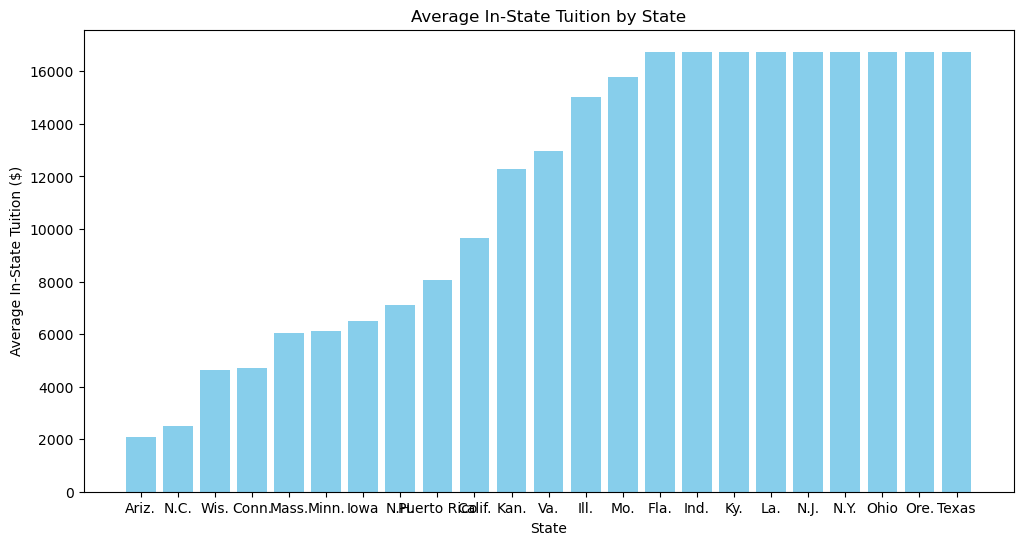

In [360]:
# create 5 visualizations that demonstrate the data you have cleansed. 
# You should have at least 2 visualizations that have data from more than one source, 
# using SQL joins (meaning, if you have 3 tables, you must have visualizations 
# that span across 2 of the tables – you are also welcome to use your consolidated dataset 
# that you created in the previous step, if you do that, you have met this requirement).

query = """
SELECT web.state, AVG(csv.fees_instate) as avg_instate_tuition
FROM college_data_csv csv  
LEFT JOIN college_data_web web ON csv.id = web.College_ID
WHERE web.state IS NOT NULL 
    AND csv.fees_instate IS NOT NULL
GROUP BY web.state
ORDER BY avg_instate_tuition;
"""

# Execute the query and fetch the results
tuition_data = pd.read_sql_query(query, conn)
tuition_data.head()

# Visulaization 1: Average in stetae tution (from csv) by web_state ( from web) 
plt.figure(figsize=(12, 6))
plt.bar(tuition_data['state'], tuition_data['avg_instate_tuition'], color='skyblue')
plt.title('Average In-State Tuition by State')
plt.xlabel('State')
plt.ylabel('Average In-State Tuition ($)')
plt.show()


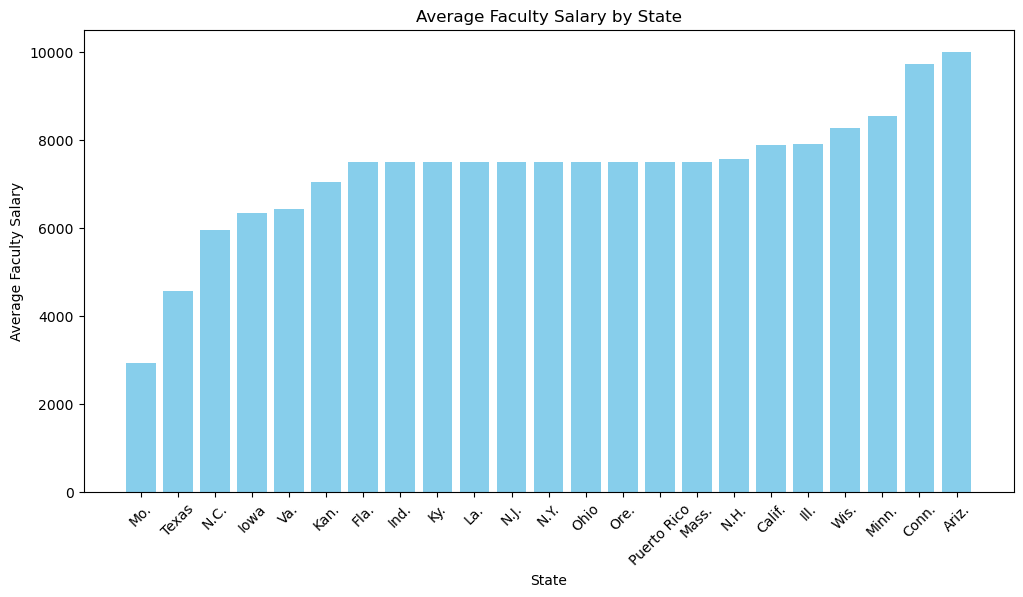

In [364]:

query = """
SELECT web.state, AVG(csv.avg_faculty_sal) as avg_faculty_salary
FROM college_data_csv csv  
LEFT JOIN college_data_web web ON csv.id = web.College_ID
WHERE web.state IS NOT NULL 
    AND csv.avg_faculty_sal IS NOT NULL
GROUP BY web.state
ORDER BY avg_faculty_salary;
"""

# Execute the query and fetch the results
avg_faculty_salary_data = pd.read_sql_query(query, conn)

# Visulaization 2: Average Faculty Salary ( from csv) by State ( from web)
plt.figure(figsize=(12, 6))
plt.bar(avg_faculty_salary_data['state'], avg_faculty_salary_data['avg_faculty_salary'], color='skyblue')
plt.title('Average Faculty Salary by State')
plt.xlabel('State')
plt.ylabel('Average Faculty Salary')
plt.xticks(rotation=45)
plt.show()

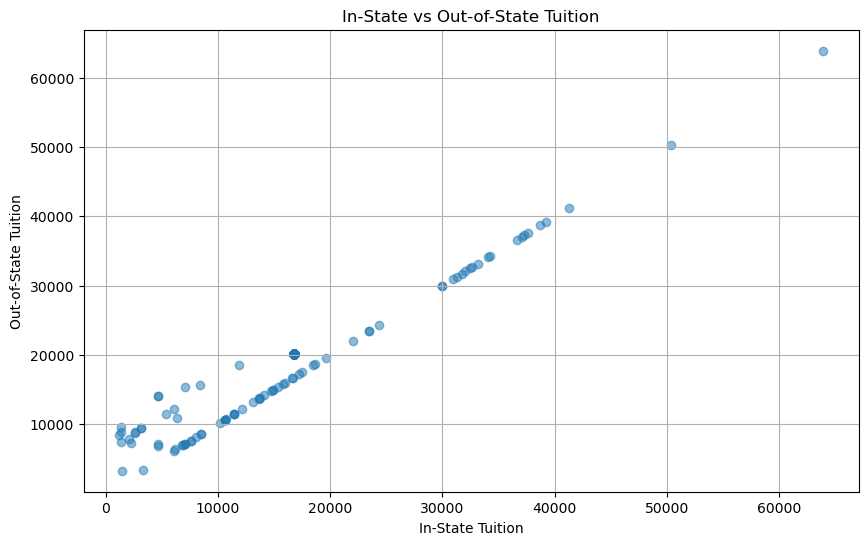

In [368]:

query = """
SELECT csv.fees_instate, csv.fees_outstate 
FROM college_data_csv csv  
WHERE csv.fees_instate IS NOT NULL 
    AND csv.fees_outstate IS NOT NULL;
"""

# Execute the query and fetch the results
tuition_data = pd.read_sql_query(query, conn)  

# Visulaization 3: Relationship between In-State Tuition and Out-of-State Tuition ( from csv) 
plt.figure(figsize=(10, 6))
plt.scatter(tuition_data['fees_instate'], tuition_data['fees_outstate'], alpha=0.5)
plt.title('In-State vs Out-of-State Tuition')
plt.xlabel('In-State Tuition')
plt.ylabel('Out-of-State Tuition')
plt.grid()
plt.show()





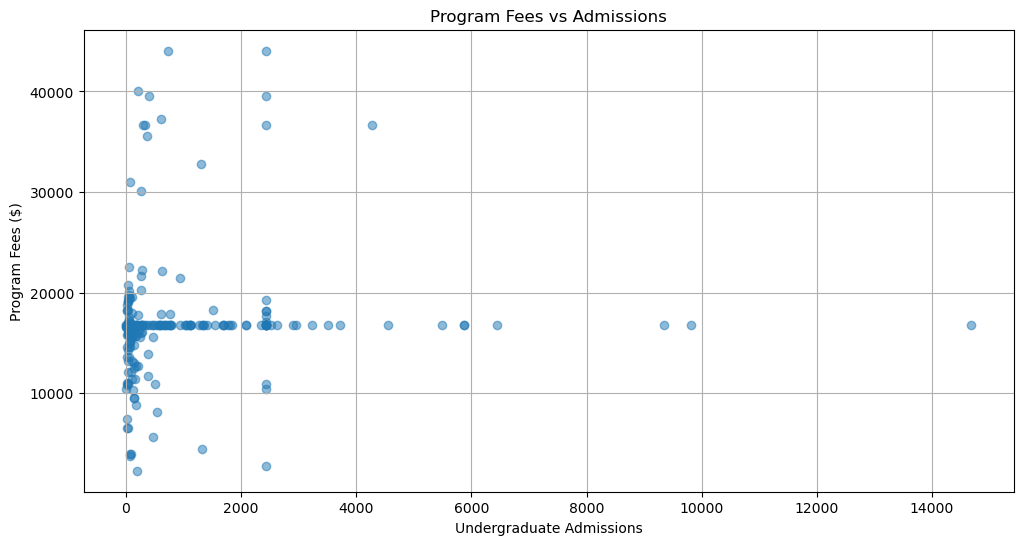

In [370]:

query = """
SELECT csv.ug_admissions, csv.program_fees
FROM college_data_csv csv
WHERE csv.ug_admissions IS NOT NULL
    AND csv.program_fees IS NOT NULL;
"""

# Execute the query and fetch the results
prog_fees = pd.read_sql_query(query, conn)

# Visulaization 4: scatter plot of Program Fees vs Admissions ( from csv) 
plt.figure(figsize=(12, 6))
plt.scatter(prog_fees['ug_admissions'], prog_fees['program_fees'], alpha=0.5)
plt.title('Program Fees vs Admissions')
plt.xlabel('Undergraduate Admissions')
plt.ylabel('Program Fees ($)')
plt.grid()
plt.show()


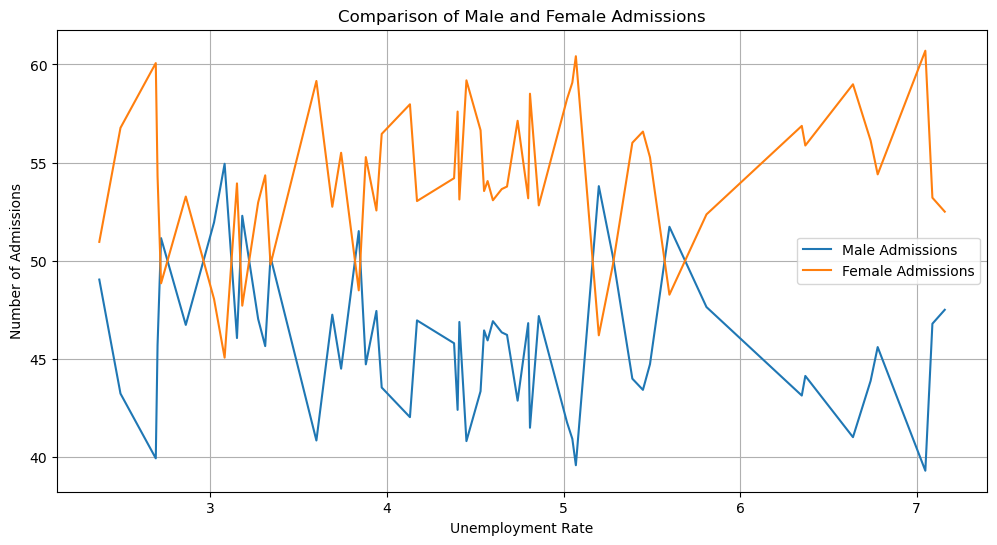

In [378]:
query = """
SELECT unemployment as api_unemployment_rate, AVG(men) as api_males_admitted, AVG(women) as api_females_admitted
FROM college_data_api api
WHERE unemployment IS NOT NULL
    AND men IS NOT NULL
    AND women IS NOT NULL
GROUP BY unemployment
ORDER BY unemployment;
"""

# Execute the query and fetch the results
df_unemployment = pd.read_sql_query(query, conn)

# Visulaization 5: line chart of admissions men & women by api_unemployment_rate
plt.figure(figsize=(12, 6))
plt.plot(df_unemployment['api_unemployment_rate'], df_unemployment['api_males_admitted'], label='Male Admissions')
plt.plot(df_unemployment['api_unemployment_rate'], df_unemployment['api_females_admitted'], label='Female Admissions')
plt.title('Comparison of Male and Female Admissions')
plt.xlabel('Unemployment Rate')
plt.ylabel('Number of Admissions')
plt.legend()
plt.grid()
plt.show()

In [384]:
query = """
SELECT csv.*, api.*, web.* 
FROM  college_data_csv csv  
INNER JOIN college_data_web web ON csv.id = web.College_ID
LEFT JOIN college_data_api api ON csv.id = api.school_id 
"""
# print data from the merged table
df_merged = pd.read_sql_query(query, conn)
print(df_merged.head())

       id     opeid              institution_name        city  state    zip  \
0  104708  107600.0    Glendale Community College    Glendale     AZ  85302   
1  110219  716400.0              Bryan University       Tempe     AZ  85281   
2  112561  770700.0              Columbia College      Sonora     CA  95370   
3  115001  120300.0    Glendale Community College    Glendale     CA  91208   
4  129695  139200.0  Manchester Community College  Manchester     CT  06040   

   fees_instate  fees_outstate  program_fees  ug_admissions  ...         city  \
0        2070.0         7854.0  16736.591244           9807  ...     Glendale   
1       12184.0        12184.0  16736.591244           1767  ...  Los Angeles   
2        1356.0         7308.0  16736.591244           1801  ...       Sonora   
3        1171.0         8371.0  16736.591244           9350  ...     Glendale   
4        4700.0        14100.0  16736.591244           3724  ...   Manchester   

    state  state_full_name  repayment_

## 250-500 word summary of what you learned and a summary of the ethical implications answering the following questions:

### What changes were made to the data?
#### The project involved extensive data transformations across three sources: CSV files, web API data, and government API data. Key transformations included standardizing column names to lowercase and replacing spaces with underscores. Also renaming them for a better human understandable descriptive names. Missing values were handled through mean/mode imputation or by using forward and backward fill methods provided within pandas, removing duplicates by key or by row method, and cleaning ZIP code formats. The data was further processed by converting decimal values to percentages and removing outliers using Z-score and IQR methods. Finally, the three datasets were merged togather into a consolidated SQLite database to create our final dataset later used to create visualizations.


### Are there any legal or regulatory guidelines for your data or project topic?
#### The project deals with educational data, which falls under FERPA (Family Educational Rights and Privacy Act) regulations. The data was sourced through official channels including government APIs (ed.gov) and authorized educational databases for public usage. All API interactions followed proper authentication protocols and rate limiting guidelines. Geographic and institutional information was handled with consideration for privacy implications, particularly when merging datasets from different sources. The data from website was a different story where I had to go thourgh the terms and conditions to use the website data under fair usage policy. Even though the main source of data for website was ed.gov data but it was protected pretty well and I had to drill down in to website to fetch the whole data accurately. This is when I did really feel that I might be doing something wrong by doing so which could be illegal.


### What risks could be created based on the transformations done?
#### The imputation of Mean/mode for missing values could mask underlying patterns and bias the final results in models. Same applies with Outlier removal which might eliminate valid but extreme cases which could be valid. Removal of duplicates based & Dataset merging could create false correlations or associations. Also, if join keys were not defined properly, could lead to bad joins between datasets. Standardization of institution names could lead to misidentification. Transforming decimal values to percentages introduced potential rounding errors.

### Did you make any assumptions in cleaning/transforming the data?
#### My first assumption was that the data provided is normal & Missing values were random and could be appropriately replaced with means/modes for numerical columns. Also, Z-scores beyond 3 standard deviations were assumed to be true outliers. Institution names could be reliably matched across datasets. ZIP codes were valid identifiers for geographic matching. Data which could be from different time periods could be meaningfully combined.

### How was your data sourced / verified for credibility?
#### The CSV was sourced from official government education statistics website and so was the api. The authorization key was requested and used while fetching the data and its fetched by accessing authorized API endpoints. The website data was validated against ed.gov data to make sure its accuracy. The legitimacy of website is confirmed by checking refrences provided by different websites.

### Was your data acquired in an ethical way?
#### Yes, the data acquisition followed ethical guidelines through official sources. The CSV and API data came directly from authorized government education statistics websites using proper authentication and API keys, while respecting usage terms and rate limits. Though some web scraping methods were used for additional data, all sources were publicly available and accessed within fair use policies, though these methods should be reviewed to ensure full compliance with terms of services.

### How would you mitigate any of the ethical implications you have identified?
#### To mitigate ethical implications, we would implement comprehensive data protection measures including encryption of sensitive information, strict FERPA compliance monitoring, and detailed documentation of all transformations. We would also establish robust data validation procedures to ensure data quality and integrity while maintaining clear audit trails, and regularly review our data handling practices against privacy regulations and ethical guidelines. Additionally, we would implement technical safeguards such as secure API authentication and rate limiting to protect against unauthorized access while ensuring transparent documentation of all methodologies used.